Detecting the chessboard using contour detection

In [119]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

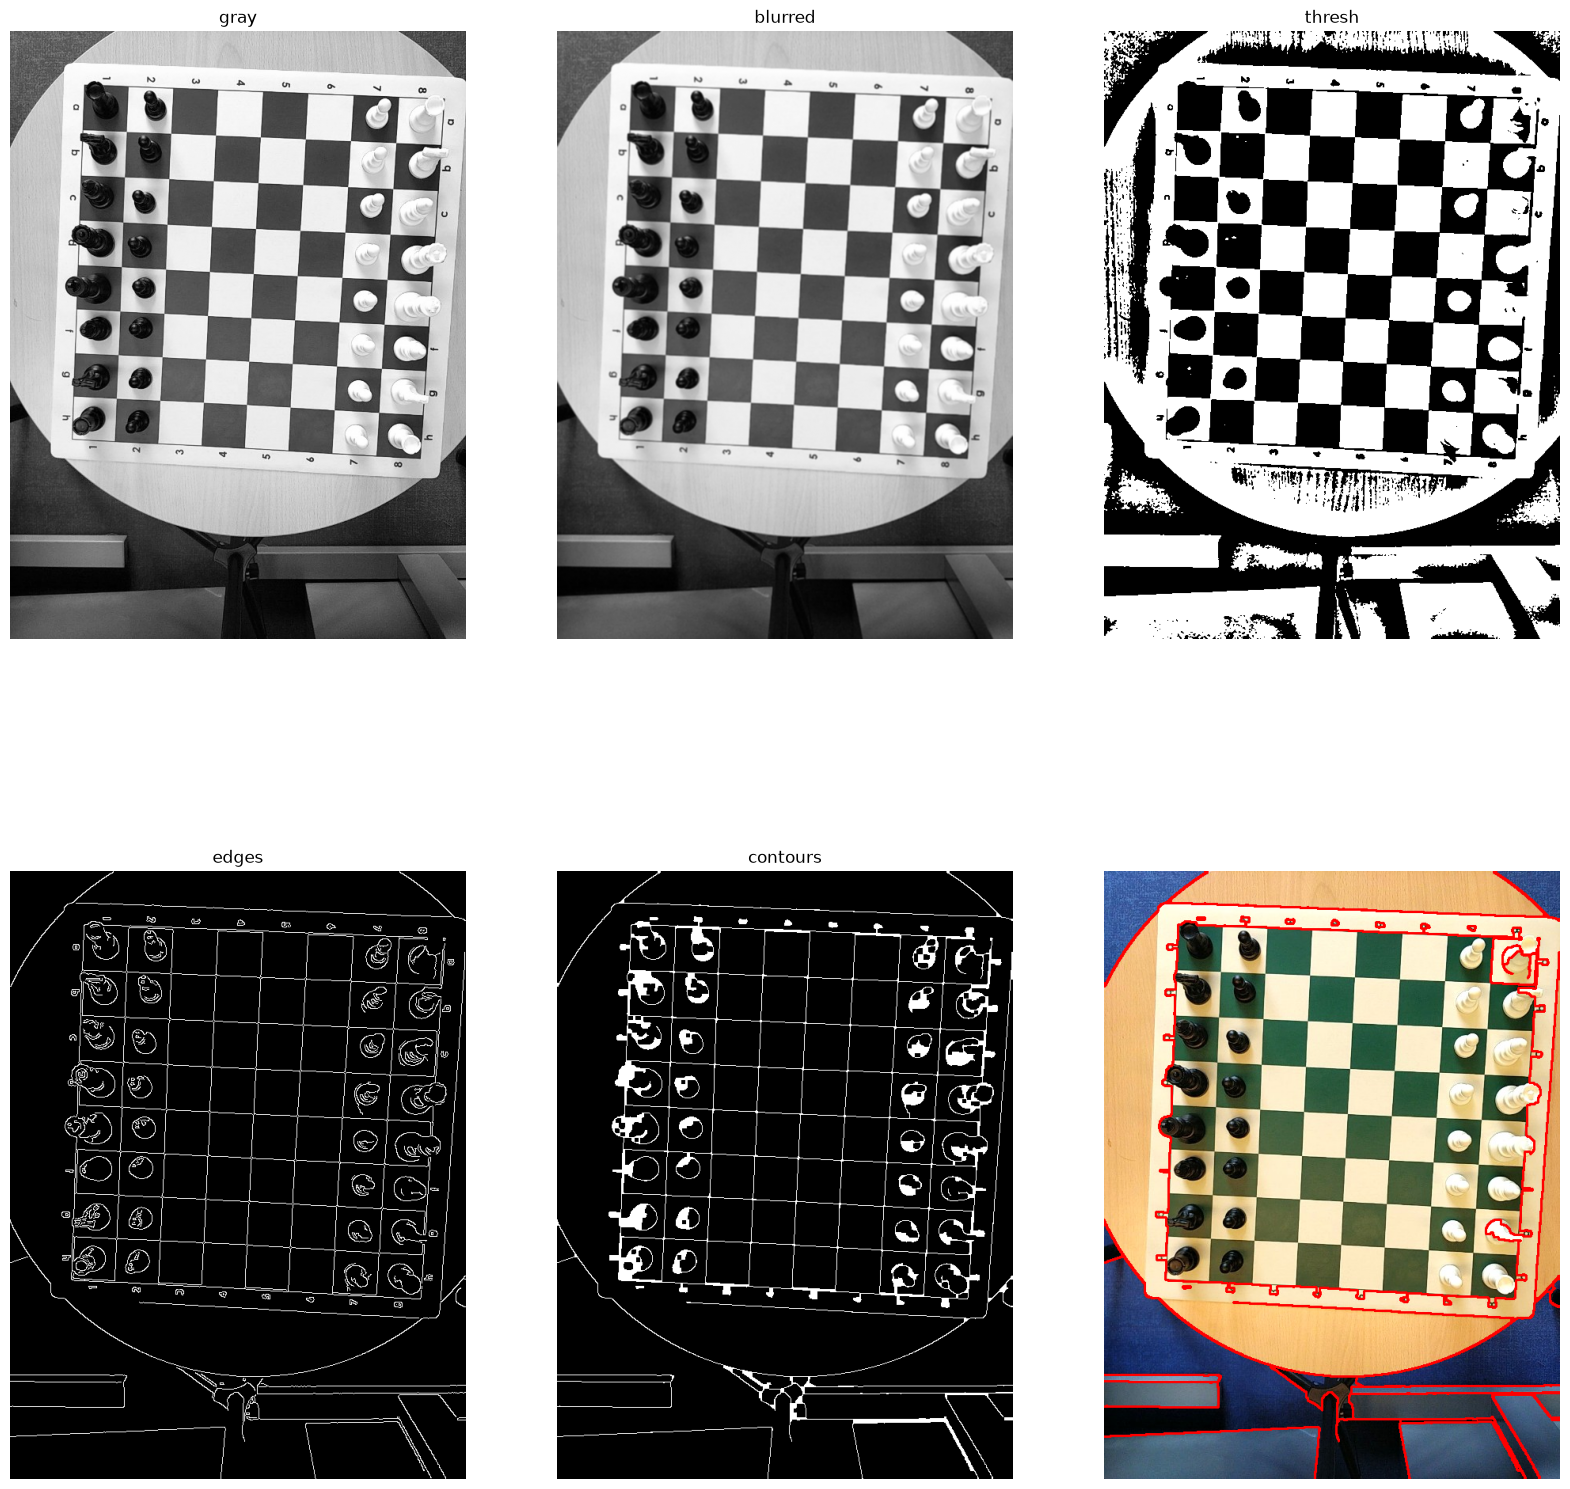

In [ ]:
image = cv2.imread('../samples/screenshot.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.subplot(2, 3, 1)
plt.title("gray")
plt.axis('off')
plt.gcf().set_size_inches(20, 20)
plt.imshow(gray, cmap='gray')

blurred = cv2.GaussianBlur(gray, (3, 3), 0)
plt.subplot(2, 3, 2)
plt.title("blurred")
plt.axis('off')
plt.imshow(blurred, cmap='gray')


threshold_kernel_size = blurred.shape[0] // 24 * 2 + 1
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, threshold_kernel_size, 3
)
plt.subplot(2, 3, 3)
plt.title("thresh")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

edges = cv2.Canny(blurred, 50, 200, None, 3)

plt.subplot(2, 3, 4)
plt.title("edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

# Close gaps in the border
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

plt.subplot(2, 3, 5)
plt.title("edges closed")
plt.imshow(edges, cmap='gray')
plt.axis('off')

contours, _ = cv2.findContours(
    edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

preview = image.copy()
cv2.drawContours(preview, contours, -1, (255, 0, 0), 2)
plt.subplot(2, 3, 6)
plt.title("contours")

plt.imshow(preview)
plt.axis('off')
plt.show()

In [121]:
# largest quadrilateral
board = None
for cnt in sorted(contours, key=cv2.contourArea, reverse=True):
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)

    if len(approx) == 4:

        board = approx.reshape(4, 2)

        tl = board[np.argmin(board.sum(axis=1))]
        br = board[np.argmax(board.sum(axis=1))]
        tr = board[np.argmin(np.diff(board, axis=1))]
        bl = board[np.argmax(np.diff(board, axis=1))]


        # Add margin to the bounding box
        margin = 0  # Adjust this value as needed
        tl = (tl[0] - margin, tl[1] - margin)
        br = (br[0] + margin, br[1] + margin)
        tr = (tr[0] + margin, tr[1] - margin)
        bl = (bl[0] - margin, bl[1] + margin)

        board = np.array([tl, tr, br, bl], dtype=np.int32)
        break


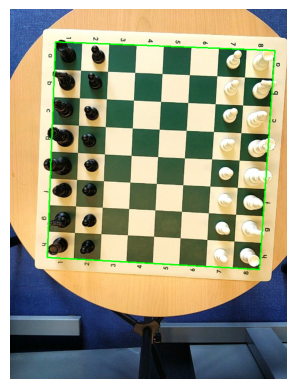

In [122]:
# Draw the bounding box on the original image
if board is not None:
    preview = image.copy()
    cv2.polylines(preview, [board], isClosed=True, color=(0, 255, 0), thickness=2)
    plt.imshow(preview)
    plt.axis('off')
    plt.show()

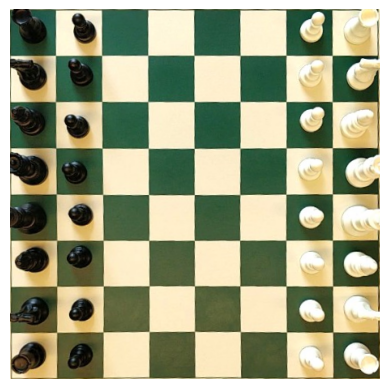

In [123]:
if board is not None:
    # Order points in clockwise order
    rect = np.zeros((4, 2), dtype="float32")
    s = board.sum(axis=1)
    rect[0] = board[np.argmin(s)]
    rect[2] = board[np.argmax(s)]

    diff = np.diff(board, axis=1)
    rect[1] = board[np.argmin(diff)]
    rect[3] = board[np.argmax(diff)]

    (tl, tr, br, bl) = rect

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_width = max(int(width_a), int(width_b))

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_height = max(int(height_a), int(height_b))

    dst = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_width, max_height))

    plt.imshow(warped)
    plt.axis('off')
    plt.show()